Эта же тетрадь, но в колабе:
https://colab.research.google.com/drive/1Ymr7bw7hBWorLIFzuFmOIuhQki2ytwMB#scrollTo=nawaKP-u9YSL



Fruits-360: A dataset of images containing fruits and vegetables

https://github.com/Horea94/Fruit-Images-Dataset

##Описание датасета
Total number of images: 90483.

Training set size: 67692 images (one fruit or vegetable per image).

Test set size: 22688 images (one fruit or vegetable per image).

Multi-fruits set size: 103 images (more than one fruit (or fruit class) per image)

Number of classes: 131 (fruits and vegetables).

Image size: 100x100 pixels.

##Загружаем данные

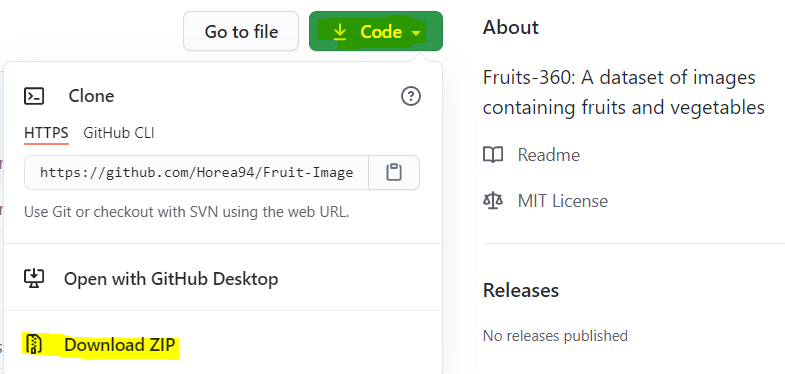

Копировать адрес ссылки на архив zip: https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip

(нажать правой кнопкой мыши на Download ZIP)

Параметр -O сохраняет файл в текущем каталоге.





In [1]:
!wget https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip -O master.zip

--2026-09-26 15:21:28--  https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master [following]
--2026-09-26 15:21:28--  https://codeload.github.com/Horea94/Fruit-Images-Dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [               <=>  ] 761.30M  20.4MB/s    in 39s     

2026-09-26 15:22:08 (19.4 MB/s) - ‘master.zip’ saved [798281972]



In [2]:
!unzip master.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/147_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/148_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/149_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/150_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/151_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/152_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/153_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/154_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/155_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/156_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/157_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato 3/158_100.jpg  
  inflating: Fruit-Images-Dataset-master/Training/Tomato

##Загружаем необходимые библиотеки и модули

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization
from tensorflow.keras import Sequential
from google.colab import files
from PIL import Image

##Генерация датасетов
Generate a Dataset

####Обучающий и проверочный датасеты

In [4]:
image_size = (100, 100)
batch_size = 512

train_ds = image_dataset_from_directory(
    "Fruit-Images-Dataset-master/Training",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
val_ds = image_dataset_from_directory(
    "Fruit-Images-Dataset-master/Training",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 67692 files belonging to 131 classes.
Using 54154 files for training.
Found 67692 files belonging to 131 classes.
Using 13538 files for validation.


In [5]:
# Посмотрим на названия классов
class_names = train_ds.class_names
class_names

['Apple Braeburn',
 'Apple Crimson Snow',
 'Apple Golden 1',
 'Apple Golden 2',
 'Apple Golden 3',
 'Apple Granny Smith',
 'Apple Pink Lady',
 'Apple Red 1',
 'Apple Red 2',
 'Apple Red 3',
 'Apple Red Delicious',
 'Apple Red Yellow 1',
 'Apple Red Yellow 2',
 'Apricot',
 'Avocado',
 'Avocado ripe',
 'Banana',
 'Banana Lady Finger',
 'Banana Red',
 'Beetroot',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe 1',
 'Cantaloupe 2',
 'Carambula',
 'Cauliflower',
 'Cherry 1',
 'Cherry 2',
 'Cherry Rainier',
 'Cherry Wax Black',
 'Cherry Wax Red',
 'Cherry Wax Yellow',
 'Chestnut',
 'Clementine',
 'Cocos',
 'Corn',
 'Corn Husk',
 'Cucumber Ripe',
 'Cucumber Ripe 2',
 'Dates',
 'Eggplant',
 'Fig',
 'Ginger Root',
 'Granadilla',
 'Grape Blue',
 'Grape Pink',
 'Grape White',
 'Grape White 2',
 'Grape White 3',
 'Grape White 4',
 'Grapefruit Pink',
 'Grapefruit White',
 'Guava',
 'Hazelnut',
 'Huckleberry',
 'Kaki',
 'Kiwi',
 'Kohlrabi',
 'Kumquats',
 'Lemon',
 'Lemon Meyer',
 'Limes',
 'Lychee',
 'M

In [6]:
# Посчитаем количество классов
len(class_names)

131

In [7]:
class_names[26]

'Cherry 1'

###Визуализация изображений

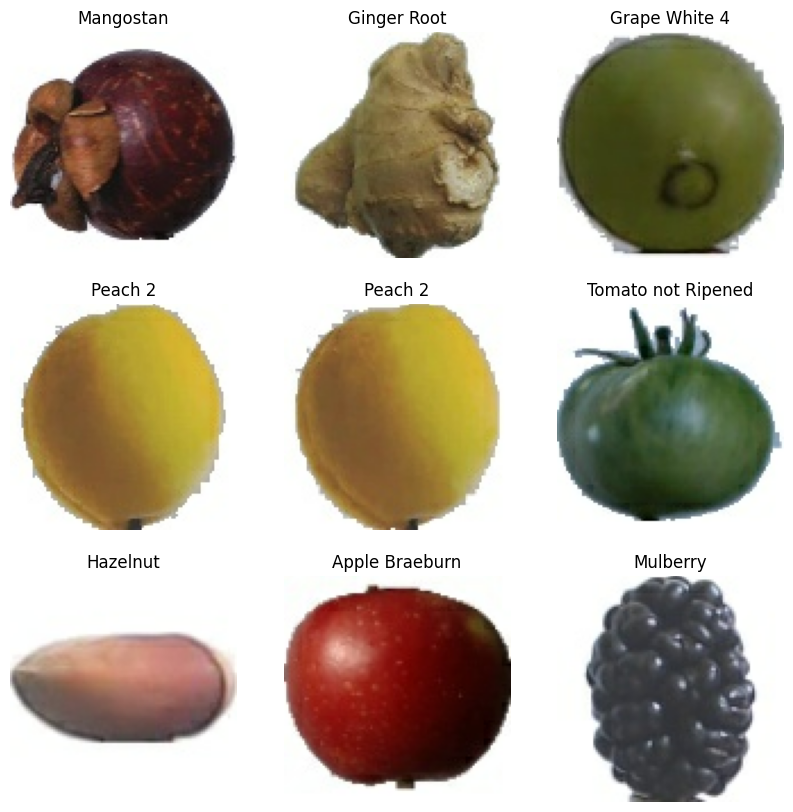

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

####Тестовый датасет

In [9]:
test_ds = image_dataset_from_directory(
    "Fruit-Images-Dataset-master/Test",
    image_size=image_size,
    batch_size=batch_size,
)

Found 22688 files belonging to 131 classes.


In [10]:
# Посмотрим на названия классов
test_ds.class_names

['Apple Braeburn',
 'Apple Crimson Snow',
 'Apple Golden 1',
 'Apple Golden 2',
 'Apple Golden 3',
 'Apple Granny Smith',
 'Apple Pink Lady',
 'Apple Red 1',
 'Apple Red 2',
 'Apple Red 3',
 'Apple Red Delicious',
 'Apple Red Yellow 1',
 'Apple Red Yellow 2',
 'Apricot',
 'Avocado',
 'Avocado ripe',
 'Banana',
 'Banana Lady Finger',
 'Banana Red',
 'Beetroot',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe 1',
 'Cantaloupe 2',
 'Carambula',
 'Cauliflower',
 'Cherry 1',
 'Cherry 2',
 'Cherry Rainier',
 'Cherry Wax Black',
 'Cherry Wax Red',
 'Cherry Wax Yellow',
 'Chestnut',
 'Clementine',
 'Cocos',
 'Corn',
 'Corn Husk',
 'Cucumber Ripe',
 'Cucumber Ripe 2',
 'Dates',
 'Eggplant',
 'Fig',
 'Ginger Root',
 'Granadilla',
 'Grape Blue',
 'Grape Pink',
 'Grape White',
 'Grape White 2',
 'Grape White 3',
 'Grape White 4',
 'Grapefruit Pink',
 'Grapefruit White',
 'Guava',
 'Hazelnut',
 'Huckleberry',
 'Kaki',
 'Kiwi',
 'Kohlrabi',
 'Kumquats',
 'Lemon',
 'Lemon Meyer',
 'Limes',
 'Lychee',
 'M

In [11]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE)

##Создаем модель


In [12]:
# Создаем последовательную модель
model = Sequential()
# Сверточный слой
model.add(Conv2D(16, (5, 5), padding = 'same', activation='relu',
                 input_shape=(100, 100, 3)))
# Слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (5, 5), padding = 'same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(64, (5, 5), padding = 'same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (5, 5), padding = 'same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Полносвязная часть нейронной сети для классификации
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
# Выходной слой
model.add(Dense(131, activation='softmax')) # 131 classes

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 131)            │        33,667 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,795,043 (10.66 MB)

 Trainable params: 2,795,043 (10.66 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras import utils

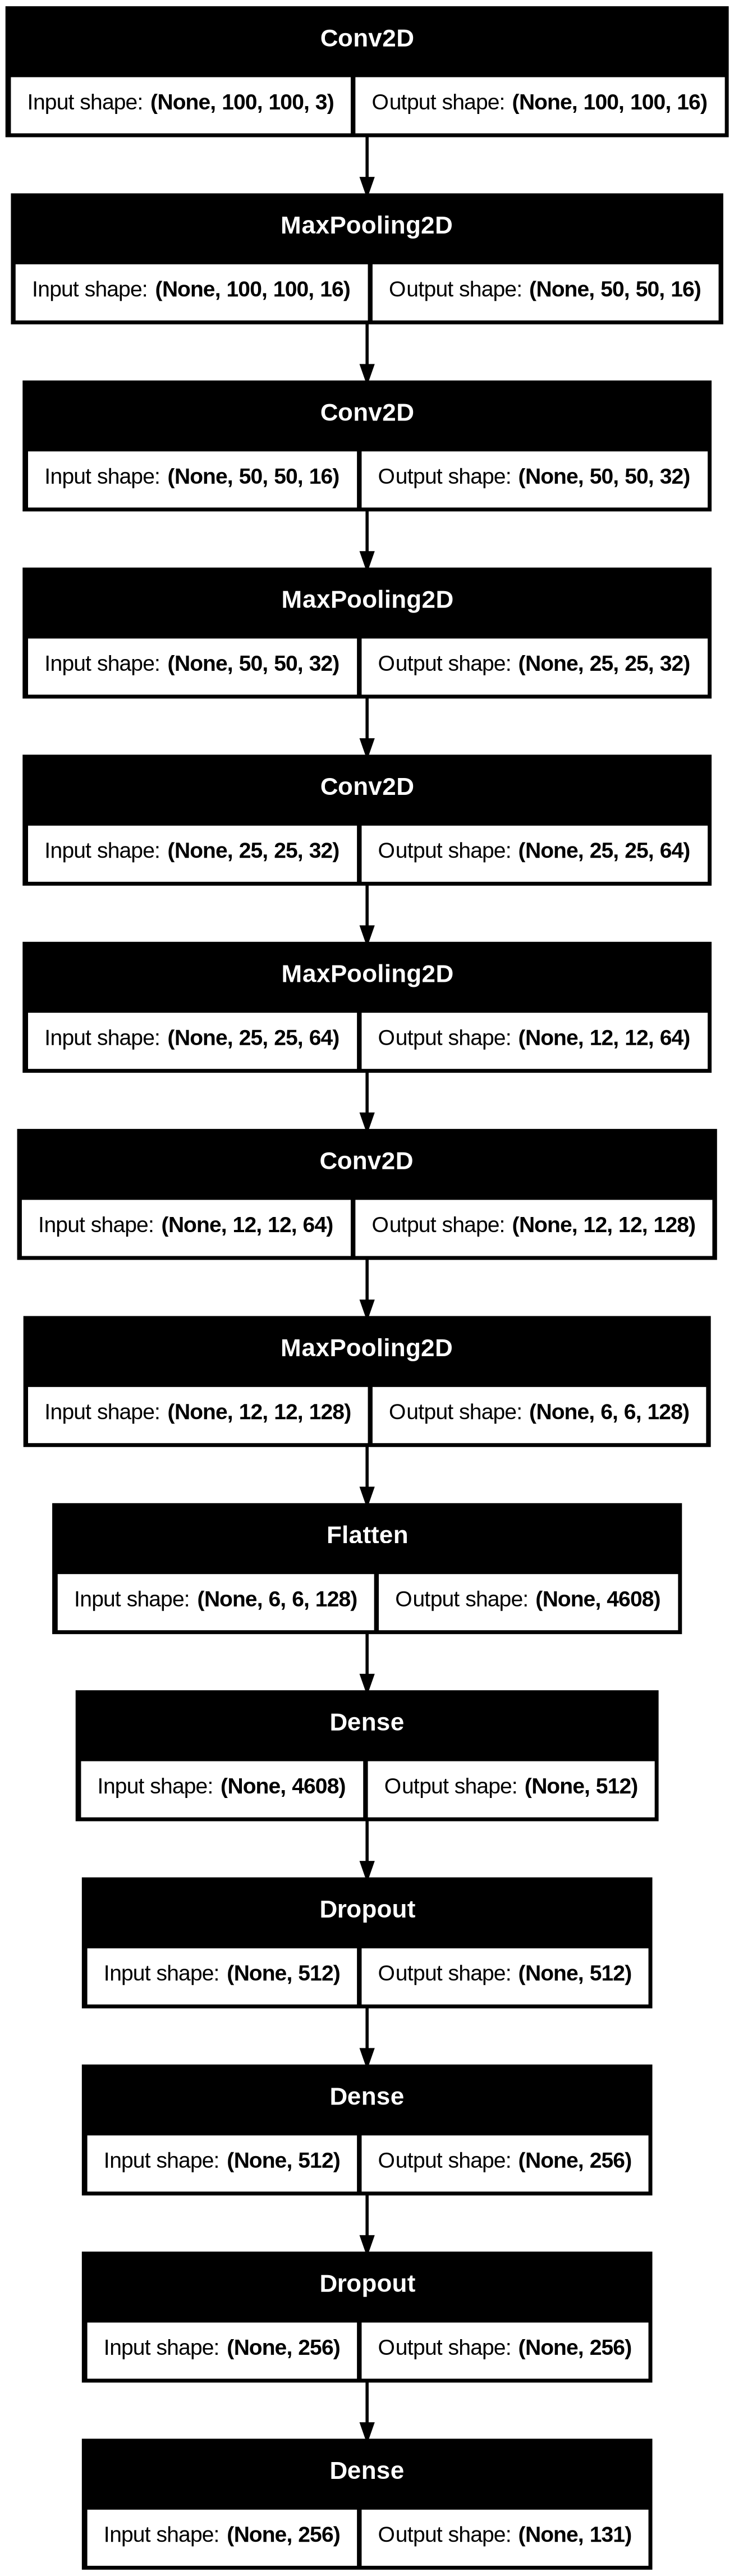

In [15]:
utils.plot_model(model, to_file='model_Fruit.png', show_shapes=True, show_layer_names=False)

In [16]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

##Обучаем модель

In [17]:
history = model.fit(train_ds,
                    validation_data = val_ds,
                    epochs=4,
                    verbose=2)

Epoch 1/4
106/106 - 52s - 487ms/step - accuracy: 0.3986 - loss: 3.1765 - val_accuracy: 0.9334 - val_loss: 0.2391
Epoch 2/4
106/106 - 47s - 441ms/step - accuracy: 0.9219 - loss: 0.2490 - val_accuracy: 0.9908 - val_loss: 0.0297
Epoch 3/4
106/106 - 21s - 195ms/step - accuracy: 0.9721 - loss: 0.0849 - val_accuracy: 0.9956 - val_loss: 0.0182
Epoch 4/4
106/106 - 21s - 195ms/step - accuracy: 0.9847 - loss: 0.0486 - val_accuracy: 0.9997 - val_loss: 0.0034


####Визуализация обучения

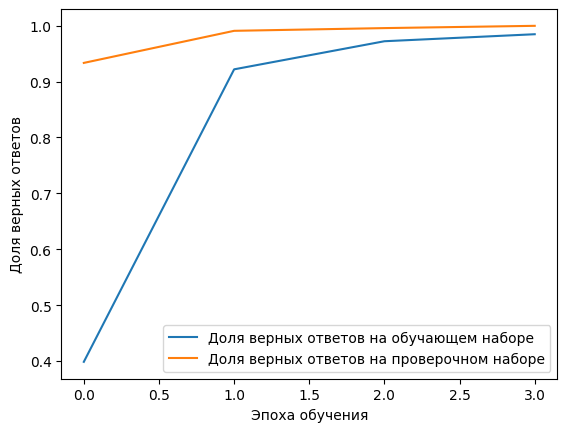

In [18]:
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

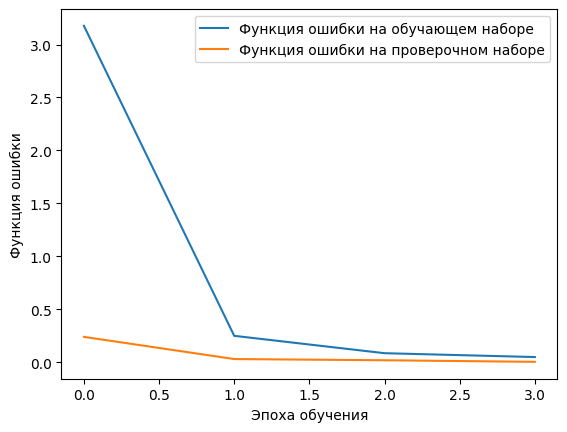

In [19]:
plt.plot(history.history['loss'],
         label='Функция ошибки на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Функция ошибки на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Функция ошибки')
plt.legend()
plt.show()

##Оцениваем качество обучения модели - метод evaluate

Метод evaluate() возвращает значения функции потерь и метрики accuracy для обученной модели:

In [20]:
scores = model.evaluate(test_ds, verbose=1)

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9545 - loss: 0.2190


In [21]:
scores

[0.21903352439403534, 0.9545133709907532]

In [22]:
print(f'Доля верных ответов на тестовых данных = {round(scores[1]*100, 2)} %')

Доля верных ответов на тестовых данных = 95.45 %


##Сохраняем обученную модель

In [23]:
model.save('Fruit-CNN.h5')

In [24]:
# загружаем на локальный диск
files.download('Fruit-CNN.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

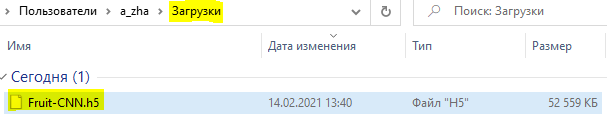

In [25]:
# загружаем на Google диск - 'путь - откуда' 'путь - куда'
!cp '/content/Fruit-CNN.h5' '/content/drive/MyDrive/ИИТм-21/Теоретические основы ИИ/Файлы для блокнотов'

cp: cannot create regular file '/content/drive/MyDrive/ИИТм-21/Теоретические основы ИИ/Файлы для блокнотов': No such file or directory


#Сохранение весов модели

In [26]:
model.save_weights('my_model_weights.h5')

ValueError: The filename must end in `.weights.h5`. Received: filepath=my_model_weights.h5

###Действия с сохраненной моделью

In [ ]:
# загрузим сохраненную модель
from keras.models import load_model
model_save = load_model("/content/drive/MyDrive/ИИТм-21/Теоретические основы ИИ/Файлы для блокнотов/Fruit-CNN.h5")

In [ ]:
#посмотрим на архитектуру загруженной модели
model_save.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 100, 100, 16)      1216      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 50, 50, 16)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 50, 50, 32)        12832     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 25, 25, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 25, 25, 64)        51264     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 12, 12, 64)       0

#Применяем модель для распознавания изображений

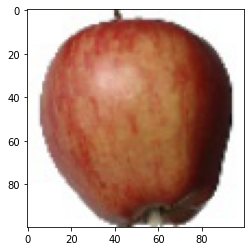

In [ ]:
filename = '/content/Fruit-Images-Dataset-master/Test/Apple Red 1/321_100.jpg'
img = image.load_img(filename, target_size=(100, 100))
plt.imshow(img)
plt.show()

In [ ]:
#Преобразуем картинку в массив
x=image.img_to_array(img)

In [ ]:
x.shape

(100, 100, 3)

In [ ]:
# Меняем форму массива
x=x.reshape(1, 100, 100, 3)
# Инвертируем изображение
#x=255-x
# Нормализуем изображение
x/=255

In [ ]:
prediction = model.predict(x)
#print(prediction)
print('\033[91m', "Возможно, это", class_names[np.argmax(prediction)]) # ANSI escape code (color management), finding the maximum in the sequence 'prediction'

 Возможно, это Apple Red 1
